In [1]:
import pandas as pd
import numpy as np
from statsmodels.tsa.arima.model import ARIMA
from arch import arch_model
import scipy.stats as st
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import tensorflow as tf


Reading in the processed data

In [2]:
df = pd.read_csv('Data/processed_demand_data.csv')
df

,settlement_date,nd,day_of_week,is_weekend,rolling_mean,rolling_std,is_holiday
0,2009-01-01,1789321,3,0,1.789321e+06,NaN,1.0
1,2009-01-02,1920721,4,0,1.855021e+06,92913.831048,0.0
2,2009-01-03,1897691,5,1,1.869244e+06,70166.941171,0.0
3,2009-01-04,1911407,6,1,1.879785e+06,61046.613643,0.0
4,2009-01-05,2181646,0,0,1.940157e+06,144979.410408,0.0
...,...,...,...,...,...,...,...
5813,2024-12-01,1302096,6,1,1.482569e+06,148823.939687,0.0
5814,2024-12-02,1501840,0,0,1.499637e+06,142115.934635,0.0
5815,2024-12-03,1632662,1,0,1.510439e+06,149869.021767,0.0
5816,2024-12-04,1588245,2,0,1.501652e+06,141932.834419,0.0


we will start by using 80% of the data for training, with the remaining being assigned to testing

In [3]:
train_size = int(0.8 * len(df)) #80% for training
train_df, test_df = df[:train_size], df[train_size:] #crreating training and testing datasets
nd_data = train_df['nd']
nd_data

0       1789321
1       1920721
2       1897691
3       1911407
4       2181646
         ...   
4649    1215489
4650    1208855
4651    1098963
4652    1192176
4653    1304597
Name: nd, Length: 4654, dtype: int64

# ARIMA + GARCH Model

We will start with a statistical model, using ARIMA and GARCH

ARIMA -> will help forecast average/expected trend

GARCH -> will forecast the time-varying uncertainty (volatility)


The ARIMA will explain the predictable patterns in returns and the GARCH will help model the uncertainty

In [4]:
arima = ARIMA(nd_data, order=(7, 1, 7))  #initializing the ARIMA model -> 7 AR terms, 0 differencing, 7 MA terms
arima_fit = arima.fit() #fitting the model
print(arima_fit.summary()) #pprinting the summary of the model
residuals = arima_fit.resid #extracting the residuals (the left over noise after fitting the ARIMA model)

/Users/rajvirthind/University Work/Data Mining /data_mining_assignment/myenv/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/Users/rajvirthind/University Work/Data Mining /data_mining_assignment/myenv/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                               SARIMAX Results                                
Dep. Variable:                     nd   No. Observations:                 4654
Model:                 ARIMA(7, 1, 7)   Log Likelihood              -58135.104
Date:                Sun, 31 Aug 2025   AIC                         116300.208
Time:                        09:30:24   BIC                         116396.887
Sample:                             0   HQIC                        116334.216
                               - 4654                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1973      0.004    -48.286      0.000      -0.205      -0.189
ar.L2          0.2431      0.006     42.497      0.000       0.232       0.254
ar.L3         -0.4131      0.003   -123.588      0.0

In [5]:
test_result = sm.stats.diagnostic.acorr_ljungbox(residuals**2, lags=[10], return_df=True) #Ljung-Box test to check for autocorrelation in the residuals
print(test_result)


      lb_stat     lb_pvalue
10  134.02862  7.027794e-24


the p value is less an 0.05 which indicates that there is sufficient evidence to suggest that ARCH effects exist in the residuals. In this case we can consider using a model that can handle conditional heteroskedasticity such as a GARCH model 

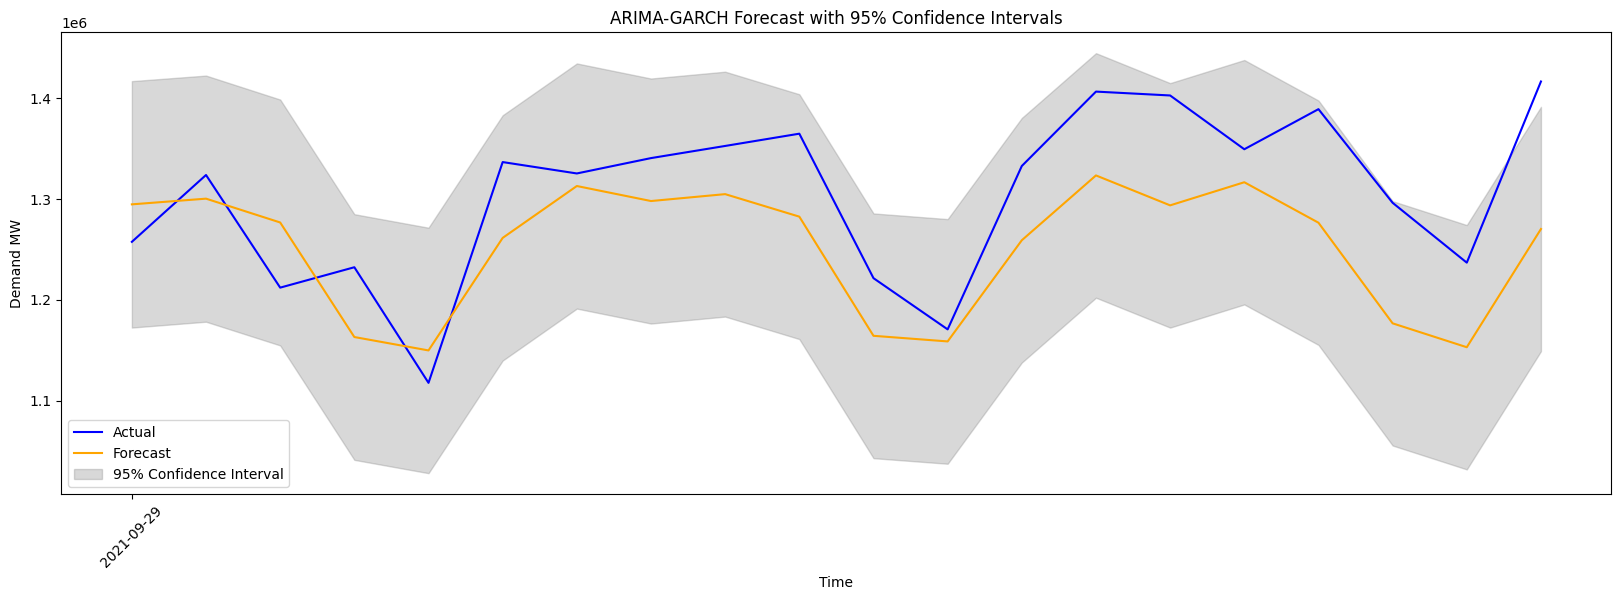

In [6]:

garch = arch_model(residuals, vol='Garch', p=1, q=1, rescale=False) #initializing the GARCH model
garch_fit = garch.fit(disp='off') #fitting the model

steps = 20#number of steps to forecast

arima_forecast = arima_fit.get_forecast(steps=steps) #forecasting using ARIMA
mean_forecast = arima_forecast.predicted_mean #extracting the mean forecast

garch_forecast = garch_fit.forecast(horizon=steps, reindex=False) #forecasting using GARCH
variance_forecast = garch_forecast.variance.values[-1, :] #extracting the variance forecast
std_dev_forecast = np.sqrt(variance_forecast) #calculating the standard deviation forecast

#95% confidence intervals
alpha = 0.05
z_score = st.norm.ppf(1 - alpha / 2)
lower_bound = mean_forecast - z_score * std_dev_forecast
upper_bound = mean_forecast + z_score * std_dev_forecast

#plotting
plt.figure(figsize=(20, 6))
plt.plot(test_df['settlement_date'][:steps], test_df['nd'][:steps], label='Actual', color='blue')
plt.plot(test_df['settlement_date'][:steps], mean_forecast, label='Forecast', color='orange')
plt.fill_between(test_df['settlement_date'][:steps], lower_bound, upper_bound, color='gray', alpha=0.3, label='95% Confidence Interval')
plt.legend()
plt.title('ARIMA-GARCH Forecast with 95% Confidence Intervals')
plt.xticks(test_df['settlement_date'][:steps][::30], rotation=45)
plt.xlabel('Time')
plt.ylabel('Demand MW')
plt.show()

In [7]:
mae = mean_absolute_error(test_df['nd'][:steps], mean_forecast)
mse = mean_squared_error(test_df['nd'][:steps], mean_forecast)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((test_df['nd'][:steps] - mean_forecast) / test_df['nd'][:steps])) * 100
print(f'MAE: {mae}, MSE: {mse}, RMSE: {rmse}, MAPE: {mape}%')

MAE: 65806.18882578859, MSE: 5629464277.703151, RMSE: 75029.75594857783, MAPE: 4.979164747158883%


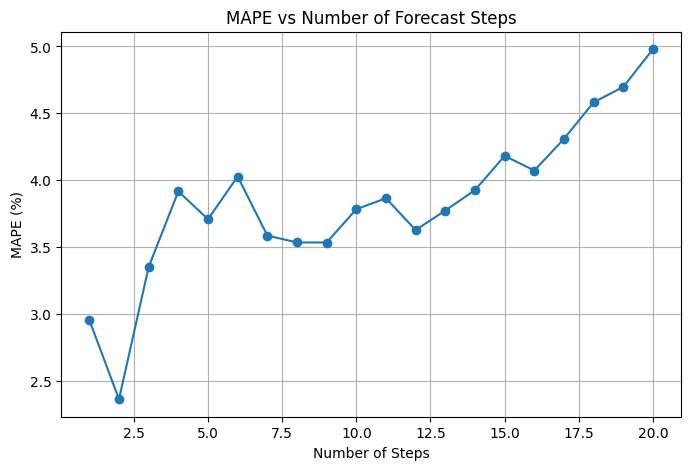

In [8]:
steps_range = range(1, 21)
mape_values = []

for s in steps_range:
    forecast = mean_forecast[:s]
    actual = test_df['nd'][:s]
    mape = np.mean(np.abs((actual - forecast) / actual)) * 100
    mape_values.append(mape)

plt.figure(figsize=(8, 5))
plt.plot(steps_range, mape_values, marker='o')
plt.xlabel('Number of Steps')
plt.ylabel('MAPE (%)')
plt.title('MAPE vs Number of Forecast Steps')
plt.grid(True)
plt.show()

model performs well in short term but very poor long term performance

# Fourier SARIMAX with GARCH

can use a fourier SARIMAX, which is a SARIMAX model that uses fourier series terms as exogenous variables to capture multiple seasonal patterns in a time series. 

- can generate multiple sine/cosine pairs for each seasonal period, acting as exogenous variables

/Users/rajvirthind/University Work/Data Mining /data_mining_assignment/myenv/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'


                               SARIMAX Results                                
Dep. Variable:                     nd   No. Observations:                 4654
Model:               SARIMAX(2, 1, 2)   Log Likelihood              -57691.046
Date:                Sun, 31 Aug 2025   AIC                         115408.092
Time:                        09:30:25   BIC                         115491.880
Sample:                             0   HQIC                        115437.566
                               - 4654                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
x1          -8.66e+04   1463.401    -59.177      0.000   -8.95e+04   -8.37e+04
x2          5.849e+04    843.532     69.335      0.000    5.68e+04    6.01e+04
x3          7.479e+04   1619.518     46.179      0.0

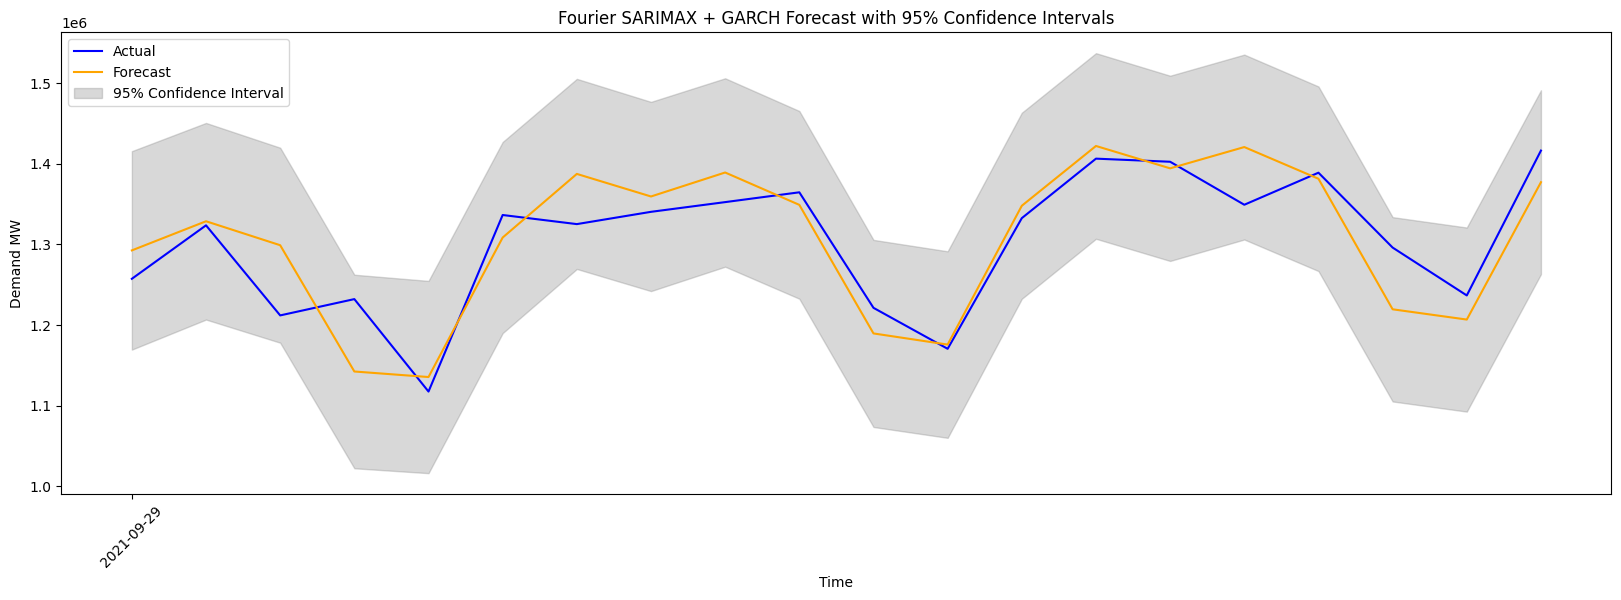

In [9]:
t = np.arange(len(nd_data))


weekly_sin = [np.sin(2 * np.pi * t * k / 7) for k in range(1, 3)] #weekly seasonality with 2 harmonics
weekly_cos = [np.cos(2 * np.pi * t * k / 7) for k in range(1, 3)]


yearly_sin = [np.sin(2 * np.pi * t * k / 365) for k in range(1, 3)] # Yearly seasonality (~365 days) with 2 harmonics
yearly_cos = [np.cos(2 * np.pi * t * k / 365) for k in range(1, 3)]


exog = np.column_stack(weekly_sin + weekly_cos + yearly_sin + yearly_cos) #combining all the fourier terms


sarimax = SARIMAX(nd_data, order=(2,1,2), exog=exog) #fitting SARIMAX model with 2 AR terms, 1 differencing, 2 MA terms and the fourier terms as exogenous variables
sarimax_fit = sarimax.fit(disp=False)
print(sarimax_fit.summary())

# Extract residuals for GARCH
residuals = sarimax_fit.resid

garch = arch_model(residuals, vol='GARCH', p=1, q=1, rescale=False)
garch_fit = garch.fit(disp='off')

steps = 20

t_forecast = np.arange(len(nd_data), len(nd_data)+steps) 

weekly_sin_fc = [np.sin(2 * np.pi * t_forecast * k / 7) for k in range(1, 3)]
weekly_cos_fc = [np.cos(2 * np.pi * t_forecast * k / 7) for k in range(1, 3)]
yearly_sin_fc = [np.sin(2 * np.pi * t_forecast * k / 365) for k in range(1, 3)]
yearly_cos_fc = [np.cos(2 * np.pi * t_forecast * k / 365) for k in range(1, 3)]

exog_fc = np.column_stack(weekly_sin_fc + weekly_cos_fc + yearly_sin_fc + yearly_cos_fc)


forecast_obj = sarimax_fit.get_forecast(steps=steps, exog=exog_fc) #forecasting using SARIMAX with the new exogenous variables
mean_forecast = forecast_obj.predicted_mean


garch_forecast = garch_fit.forecast(horizon=steps, reindex=False) #forecasting using GARCH
variance_forecast = garch_forecast.variance.values[-1, :]
std_dev_forecast = np.sqrt(variance_forecast)


alpha = 0.05 #95% confidence intervals
z_score = st.norm.ppf(1 - alpha / 2)
lower_bound = mean_forecast - z_score * std_dev_forecast
upper_bound = mean_forecast + z_score * std_dev_forecast


plt.figure(figsize=(20, 6))
plt.plot(test_df['settlement_date'][:steps], test_df['nd'][:steps], label='Actual', color='blue')
plt.plot(test_df['settlement_date'][:steps], mean_forecast, label='Forecast', color='orange')
plt.fill_between(test_df['settlement_date'][:steps], lower_bound, upper_bound, color='gray', alpha=0.3, label='95% Confidence Interval')
plt.legend()
plt.title('Fourier SARIMAX + GARCH Forecast with 95% Confidence Intervals')
plt.xticks(test_df['settlement_date'][:steps][::30], rotation=45)
plt.xlabel('Time')
plt.ylabel('Demand MW')
plt.show()

In [10]:
mae = mean_absolute_error(test_df['nd'][:steps], mean_forecast)
mse = mean_squared_error(test_df['nd'][:steps], mean_forecast)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((test_df['nd'][:steps] - mean_forecast) / test_df['nd'][:steps])) * 100
print(f'MAE: {mae}, MSE: {mse}, RMSE: {rmse}, MAPE: {mape}%')

MAE: 34865.882848439636, MSE: 1942671987.121341, RMSE: 44075.75282534991, MAPE: 2.7070873199371914%


# LSTM model

need to scale features

In [11]:
df = df.dropna() #dropping any NaN values
df

,settlement_date,nd,day_of_week,is_weekend,rolling_mean,rolling_std,is_holiday
1,2009-01-02,1920721,4,0,1.855021e+06,92913.831048,0.0
2,2009-01-03,1897691,5,1,1.869244e+06,70166.941171,0.0
3,2009-01-04,1911407,6,1,1.879785e+06,61046.613643,0.0
4,2009-01-05,2181646,0,0,1.940157e+06,144979.410408,0.0
5,2009-01-06,2266786,1,0,1.994595e+06,186000.768059,0.0
...,...,...,...,...,...,...,...
5813,2024-12-01,1302096,6,1,1.482569e+06,148823.939687,0.0
5814,2024-12-02,1501840,0,0,1.499637e+06,142115.934635,0.0
5815,2024-12-03,1632662,1,0,1.510439e+06,149869.021767,0.0
5816,2024-12-04,1588245,2,0,1.501652e+06,141932.834419,0.0


Epoch 1/20


/Users/rajvirthind/University Work/Data Mining /data_mining_assignment/myenv/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


130/130 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0392 - val_loss: 0.0070
Epoch 2/20
130/130 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0167 - val_loss: 0.0069
Epoch 3/20
130/130 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0143 - val_loss: 0.0068
Epoch 4/20
130/130 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0127 - val_loss: 0.0068
Epoch 5/20
130/130 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0117 - val_loss: 0.0062
Epoch 6/20
130/130 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0102 - val_loss: 0.0069
Epoch 7/20
130/130 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0091 - val_loss: 0.0059
Epoch 8/20
130/130 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0090 - val_loss: 0.0059
Epoch 9/20
130/130 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0084 - val_loss: 0.0057
Epoch 10/20
130/130 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0082 - val_loss: 0.0063
Epoch 11/20
130/130 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0079 - val_loss: 0.0060
Epoch 12/20
130/130 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.

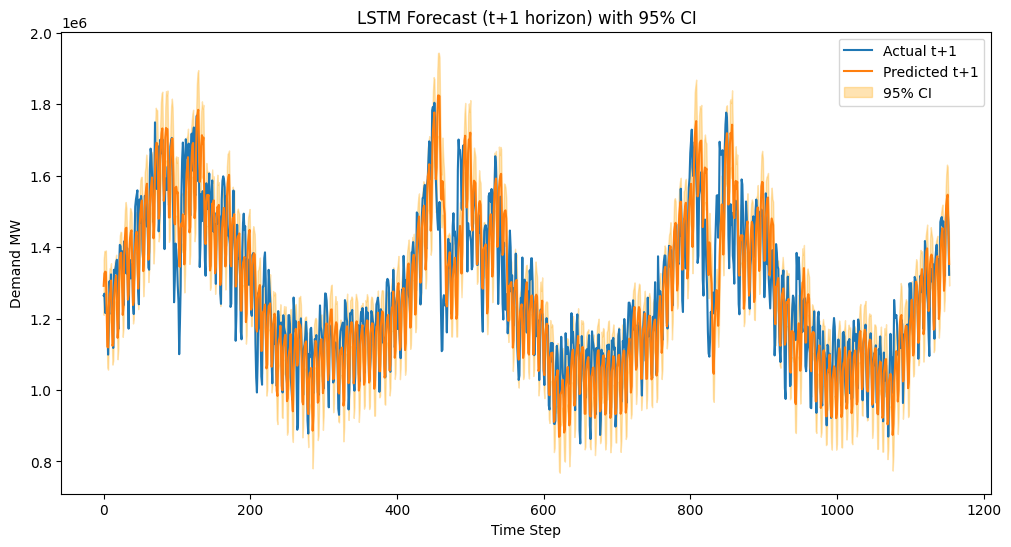

In [ ]:
df['settlement_date'] = pd.to_datetime(df['settlement_date'])

features = ['day_of_week', 'is_holiday', 'is_weekend', 'rolling_mean', 'rolling_std'] #features to be used for LSTM
target = 'nd' #target variable

scaler= MinMaxScaler() #scaling the features and target variable to [0, 1] range
scaled_data = scaler.fit_transform(df[features + [target]]) #fitting and transforming the data

def create_sequences(data, seq_length, n_steps_out=20): #function to create sequence of data for LSTM
    X, y = [], []
    for i in range(len(data) - seq_length - n_steps_out + 1): #sliding window approach
        X.append(data[i:i + seq_length, :-1])             # features
        y.append(data[i + seq_length : i + seq_length + n_steps_out, -1])  # next 20 target values
    return np.array(X), np.array(y)

num_steps_out = 20
seq_length = 30
X, y = create_sequences(scaled_data, seq_length, num_steps_out)
train_size = int(0.8 * len(X))
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(seq_length, len(features))),
    Dropout(0.2),
    LSTM(50),
    Dropout(0.2),
    Dense(num_steps_out)  # Output layer with 20 units for multi-step forecasting
])

model.compile(optimizer='adam', loss='mean_squared_error')
model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.1, verbose=1)

def mc_dropout_predict(model, X, n_simulations=100):
    f = tf.function(lambda x: model(x, training=True))
    preds = np.stack([f(X).numpy().squeeze() for _ in range(n_simulations)], axis=0)
    return preds

y_pred_samples = mc_dropout_predict(model, X_test, n_simulations=100)

y_pred_mean = y_pred_samples.mean(axis=0)
lower = np.percentile(y_pred_samples, 2.5, axis=0)
upper = np.percentile(y_pred_samples, 97.5, axis=0)

def inverse_transform(y_scaled):
    y_scaled = y_scaled.reshape(-1)  # flatten
    dummy = np.zeros((len(y_scaled), len(features) + 1))
    dummy[:, -1] = y_scaled
    y_rescaled = scaler.inverse_transform(dummy)[:, -1]
    return y_rescaled.reshape(-1, num_steps_out)  # reshape back


y_test_rescaled = inverse_transform(y_test)
y_pred_mean_rescaled = inverse_transform(y_pred_mean)
lower_rescaled = inverse_transform(lower)
upper_rescaled = inverse_transform(upper)

mae = mean_absolute_error(y_test_rescaled.flatten(), y_pred_mean_rescaled.flatten())
mse = mean_squared_error(y_test_rescaled.flatten(), y_pred_mean_rescaled.flatten())
rmse = np.sqrt(mse)
mape = np.mean(
    np.abs((y_test_rescaled.flatten() - y_pred_mean_rescaled.flatten()) / y_test_rescaled.flatten())
) * 100

print(f'MAE: {mae}, MSE: {mse}, RMSE: {rmse}, MAPE: {mape:.2f}%')

plt.figure(figsize=(12,6))
plt.plot(y_test_rescaled[:, 0], label="Actual t+1")
plt.plot(y_pred_mean_rescaled[:, 0], label="Predicted t+1")
plt.fill_between(range(len(y_pred_mean_rescaled)), 
                 lower_rescaled[:, 0], upper_rescaled[:, 0],
                 color="orange", alpha=0.3, label="95% CI")
plt.xlabel("Time Step")
plt.ylabel("Demand MW")
plt.title("LSTM Forecast (t+1 horizon) with 95% CI")
plt.legend()
plt.show()
